In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
import seaborn as sns
import time

In [2]:
def load_emnist(path):
    data= pd.read_csv(path)
    y= data.iloc[:,0].values
    X= data.iloc[:,1:].values
    return X,y

In [3]:
def preprocess(X, y, test_size=0.2, random_state= 42):
    X= X/255.0
    X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= test_size, 
                                                       random_state= random_state, stratify= y
                                                      )
    return X_train, X_test, y_train, y_test

In [4]:
def extract_features(X_train, X_test):
    # For basic ML approach, we'll use raw pixels
    # Could add dimensionalit
    return X_train, X_test

In [8]:
def train_and_evaluate(X_train, X_test, y_train, y_test):
    models = {
        "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1),
        "SVM": SVC(kernel='rbf', C=10, gamma='scale'),
        "Logistic Regression": LogisticRegression( solver='lbfgs', max_iter=1000)
    }
    
    results = {}
    for name, model in models.items():
        start = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - start
        
        start = time.time()
        y_pred = model.predict(X_test)
        predict_time = time.time() - start
        
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        cm = confusion_matrix(y_test, y_pred)
        
        results[name] = {
            'model': model,
            'accuracy': accuracy,
            'f1_score': f1,
            'confusion_matrix': cm,
            'train_time': train_time,
            'predict_time': predict_time
        }
        
        print(f"\n{name} Results:")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"F1 Score: {f1:.4f}")
        print(f"Training Time: {train_time:.2f}s")
        print(f"Prediction Time: {predict_time:.2f}s")
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f'Confusion Matrix - {name}')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()
    
    return results

In [9]:
# Main workflow
def main_ml():
    # Load data (update path)
    X, y = load_emnist('A:\divya\Divya_Github\CodeAlpha_HandWrittenCharacterRecognition\emnist-digits-train.csv')
    
    # Preprocess
    X_train, X_test, y_train, y_test = preprocess(X, y)
    
    # Feature engineering
    X_train_fe, X_test_fe = extract_features(X_train, X_test)
    
    # Train and evaluate
    results = train_and_evaluate(X_train_fe, X_test_fe, y_train, y_test)
    
    # Compare models
    print("\nModel Comparison:")
    for name, res in results.items():
        print(f"{name}: Accuracy={res['accuracy']:.4f}, F1={res['f1_score']:.4f}")



Random Forest Results:
Accuracy: 0.9808
F1 Score: 0.9808
Training Time: 68.28s
Prediction Time: 1.01s

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4800
           1       0.99      0.99      0.99      4800
           2       0.98      0.99      0.98      4800
           3       0.98      0.97      0.97      4800
           4       0.97      0.99      0.98      4800
           5       0.98      0.98      0.98      4800
           6       0.99      0.99      0.99      4800
           7       0.99      0.98      0.98      4800
           8       0.98      0.97      0.97      4800
           9       0.97      0.97      0.97      4800

    accuracy                           0.98     48000
   macro avg       0.98      0.98      0.98     48000
weighted avg       0.98      0.98      0.98     48000



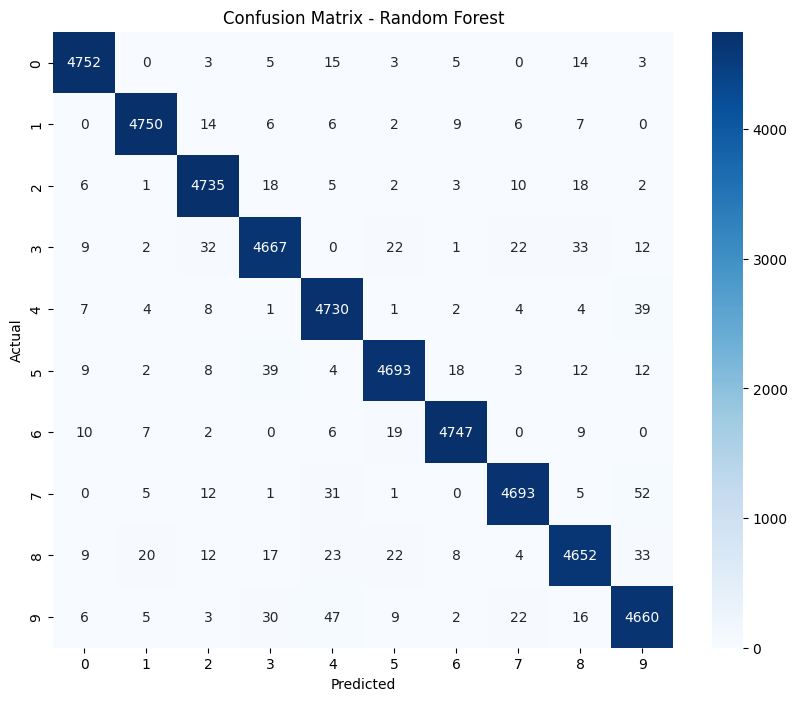

In [ ]:
if __name__ == "__main__":
    main_ml()